In [77]:
project_description = """
Problem Statement
This study analyzes and forecasts global electric vehicle (EV) growth using machine learning methods. EV growth has accelerated due to technological advances, declining costs, and supportive environmental policies, but this non-linear pattern makes traditional linear models less accurate. The study evaluates multiple regression and classification models to identify those that best capture accelerating growth and provide reliable long-term EV sales forecasts for planning, infrastructure, energy management, and investment decisions.

Model Outcomes and Predictions
This project uses supervised learning because historical EV data with known outcomes is available. Two tasks were performed: regression and classification.
Regression was used to predict future global EV sales. The models used were Linear Regression, Polynomial Regression, KNN Regressor, and Decision Tree Regressor.
Classification was used to label EV adoption as above or below the median. The models used were Logistic Regression, KNN, Decision Tree, and SVM.

Data Acquisition
The dataset was compiled from global EV statistics, containing EV sales, EV stock, EV sales share, EV stock share.The data spans multiple years (2010–2023) and includes global and regional observations. Using multiple indicators allows the model to capture both adoption levels and growth dynamics. 
The outputs are future EV sales forecasts and binary adoption labels.
Data Sources: https://www.kaggle.com/datasets/jainaru/electric-car-sales-2010-2024

Data Preprocessing/Preparation
Missing values were identified and removed, duplicate records were deleted, and measurement units were standardized. The data was split into 80% training and 20% testing sets using a fixed random seed to ensure consistent results.Categorical variables were encoded as needed, and numerical features were scaled for models such as KNN and SVM. Feature processing focused on capturing year-based trends and EV adoption patterns.

Modeling
Based on the problem, several regression and classification models were selected. For regression, the models used were Linear Regression, Polynomial Regression, KNN Regressor, and Decision Tree Regressor.
For classification, the models used were Logistic Regression, KNN, Decision Tree, and SVM. Using multiple models allowed comparison of accuracy, interpretability, and forecasting performance.

Model Evaluation
Regression models were evaluated based on how well they captured trends and future growth, while classification models were evaluated on their ability to distinguish high and low EV adoption.
Performance was measured using visual trend analysis for regression and accuracy, ROC-AUC, and confusion matrices for classification.

Results
Polynomial Regression performed best for long-term EV sales forecasting because it captured accelerating growth. Linear Regression underestimated future growth, while KNN and Decision Tree regressors produced flat forecasts. 
For classification, the tuned SVM achieved the highest ROC-AUC, with Logistic Regression offering the best balance between performance and interpretability.
"""

print(project_description)



Problem Statement
This study analyzes and forecasts global electric vehicle (EV) growth using machine learning methods. EV growth has accelerated due to technological advances, declining costs, and supportive environmental policies, but this non-linear pattern makes traditional linear models less accurate. The study evaluates multiple regression and classification models to identify those that best capture accelerating growth and provide reliable long-term EV sales forecasts for planning, infrastructure, energy management, and investment decisions.

Model Outcomes and Predictions
This project uses supervised learning because historical EV data with known outcomes is available. Two tasks were performed: regression and classification.
Regression was used to predict future global EV sales. The models used were Linear Regression, Polynomial Regression, KNN Regressor, and Decision Tree Regressor.
Classification was used to label EV adoption as above or below the median. The models used wer

In [78]:
import pandas as pd
import numpy as np 
import pandas as pd 
import time

from sklearn import preprocessing, metrics
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.svm import LinearSVC

In [3]:
print("Data Overview: Rows: 1,342 & Columns: 8")
print('''
region --> Geographic area (e.g., Australia, World)
category --> Data type (Historical)
parameter --> Metric measured (EV sales)
mode --> Vehicle type (Cars)
powertrain --> Technology (BEV, PHEV, FCEV)
year --> Calendar year
unit --> Measurement unit (Vehicles)
value --> Number of vehicles sold''')

Data Overview: Rows: 1,342 & Columns: 8

region --> Geographic area (e.g., Australia, World)
category --> Data type (Historical)
parameter --> Metric measured (EV sales)
mode --> Vehicle type (Cars)
powertrain --> Technology (BEV, PHEV, FCEV)
year --> Calendar year
unit --> Measurement unit (Vehicles)
value --> Number of vehicles sold


In [4]:
#loads a CSV file
df = pd.read_csv('data/IEA-EV-dataEV salesHistoricalCars.csv')

In [5]:
 #Displays the first 5 rows of the dataset
df.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
2,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [6]:
 #Displays the last 5 rows of the dataset
df.tail()

,region,category,parameter,mode,powertrain,year,unit,value
3793,World,Historical,EV stock,Cars,BEV,2023,Vehicles,28000000.0
3794,World,Historical,EV sales,Cars,BEV,2023,Vehicles,9500000.0
3795,World,Historical,EV sales share,Cars,EV,2023,percent,18.0
3796,World,Historical,EV stock share,Cars,EV,2023,percent,3.2
3797,World,Historical,Electricity demand,Cars,EV,2023,GWh,97000.0


In [7]:
#Checks the data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   object 
 1   category    3798 non-null   object 
 2   parameter   3798 non-null   object 
 3   mode        3798 non-null   object 
 4   powertrain  3798 non-null   object 
 5   year        3798 non-null   int64  
 6   unit        3798 non-null   object 
 7   value       3798 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 237.5+ KB


In [8]:
#shows the(rows, columns)
df.shape

(3798, 8)

In [9]:
#Lists all column names in the dataset
df.columns

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='object')

In [10]:
#count the number of unique values in each column
df.nunique()

region         52
category        1
parameter       7
mode            1
powertrain      4
year           14
unit            5
value         814
dtype: int64

In [11]:
# statistical summary of data
df.describe()

,year,value
count,3798.000000,3.798000e+03
mean,2017.369932,1.009542e+05
std,3.809226,8.184402e+05
min,2010.000000,1.500000e-05
25%,2014.000000,2.300000e+00
50%,2018.000000,1.900000e+02
75%,2021.000000,6.800000e+03
max,2023.000000,2.800000e+07


In [12]:
#removes duplicate rows
df = df.drop_duplicates()

In [13]:
#checking missing values
df.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

In [14]:
#removes rows where either year or value is missing (NaN)
df = df.dropna(subset=["year", "value"])

In [15]:
ev_sales = df[df["parameter"] == "EV sales"]
ev_sales

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.0
6,Australia,Historical,EV sales,Cars,PHEV,2012,Vehicles,80.0
9,Australia,Historical,EV sales,Cars,BEV,2012,Vehicles,170.0
10,Australia,Historical,EV sales,Cars,BEV,2013,Vehicles,190.0
13,Australia,Historical,EV sales,Cars,PHEV,2013,Vehicles,100.0
...,...,...,...,...,...,...,...,...
3781,World,Historical,EV sales,Cars,FCEV,2022,Vehicles,15000.0
3783,World,Historical,EV sales,Cars,PHEV,2022,Vehicles,2900000.0
3788,World,Historical,EV sales,Cars,PHEV,2023,Vehicles,4300000.0
3792,World,Historical,EV sales,Cars,FCEV,2023,Vehicles,8900.0


In [16]:
ev_sales_share = df[df["parameter"] == "EV sales share"]
ev_sales_share

,region,category,parameter,mode,powertrain,year,unit,value
2,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.0065
7,Australia,Historical,EV sales share,Cars,EV,2012,percent,0.0300
12,Australia,Historical,EV sales share,Cars,EV,2013,percent,0.0340
19,Australia,Historical,EV sales share,Cars,EV,2014,percent,0.1600
24,Australia,Historical,EV sales share,Cars,EV,2015,percent,0.2000
...,...,...,...,...,...,...,...,...
3751,World,Historical,EV sales share,Cars,EV,2019,percent,2.6000
3756,World,Historical,EV sales share,Cars,EV,2020,percent,4.2000
3773,World,Historical,EV sales share,Cars,EV,2021,percent,8.9000
3778,World,Historical,EV sales share,Cars,EV,2022,percent,14.0000


In [17]:
df.groupby("year")["value"].count()

year
2010    135
2011    182
2012    203
2013    223
2014    238
2015    287
2016    289
2017    294
2018    301
2019    319
2020    321
2021    338
2022    336
2023    332
Name: value, dtype: int64

In [18]:
df.groupby("powertrain")["value"].count()

powertrain
BEV     1078
EV      1311
FCEV     487
PHEV     922
Name: value, dtype: int64

In [19]:
ev_sales = df[df["parameter"] == "EV sales"]

global_sales = (
    ev_sales
    .groupby("year")["value"]
    .sum()
    .reset_index()
)
global_sales

,year,value
0,2010,17481.0
1,2011,116745.0
2,2012,285910.0
3,2013,510334.0
4,2014,810712.2
5,2015,1412771.0
6,2016,1852523.0
7,2017,2825756.0
8,2018,4735114.0
9,2019,5177232.0


In [20]:
us_df = df[df["region"] == "World"]

us_powertrain_year = (
    us_df
    .groupby(["year", "powertrain"])["value"]
    .sum()
    .reset_index()
)

us_powertrain_year


,year,powertrain,value
0,2010,BEV,2.700000e+04
1,2010,EV,4.620137e+02
2,2010,FCEV,7.400000e+01
3,2010,PHEV,8.500000e+02
4,2011,BEV,9.800000e+04
5,2011,EV,1.681077e+03
6,2011,FCEV,1.210000e+02
7,2011,PHEV,1.850000e+04
8,2012,BEV,1.790000e+05
9,2012,EV,1.980183e+03


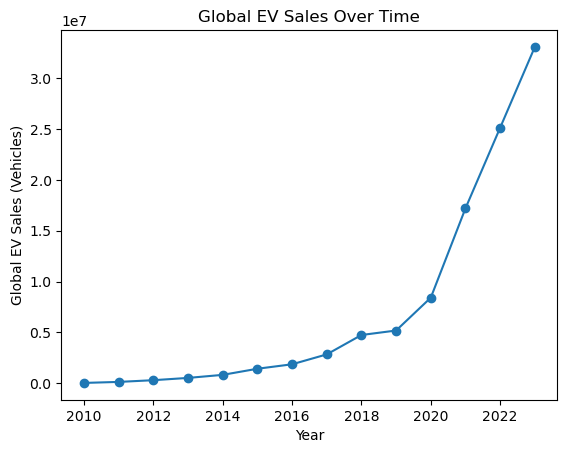

In [21]:
plt.figure()
plt.plot(global_sales["year"], global_sales["value"], marker="o")
plt.xlabel("Year")
plt.ylabel("Global EV Sales (Vehicles)")
plt.title("Global EV Sales Over Time")
plt.show()



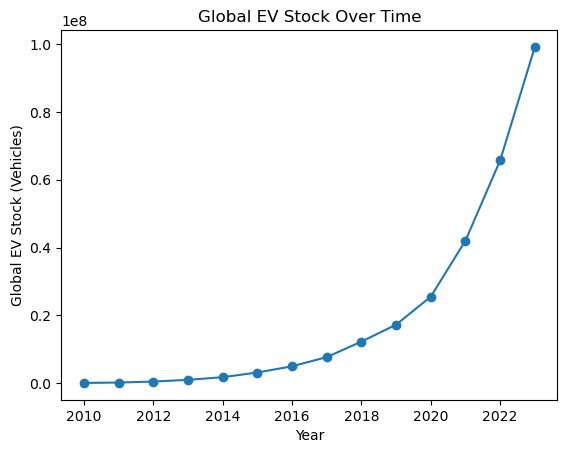

In [22]:
ev_stock = df[df["parameter"] == "EV stock"]

global_stock = (
    ev_stock
    .groupby("year")["value"]
    .sum()
    .reset_index()
)

plt.figure()
plt.plot(global_stock["year"], global_stock["value"], marker="o")
plt.xlabel("Year")
plt.ylabel("Global EV Stock (Vehicles)")
plt.title("Global EV Stock Over Time")
plt.show()


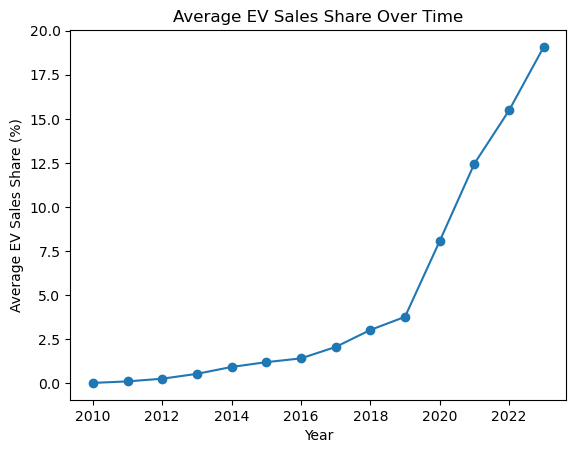

In [23]:
ev_sales_share = df[df["parameter"] == "EV sales share"]

avg_sales_share = (
    ev_sales_share
    .groupby("year")["value"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(avg_sales_share["year"], avg_sales_share["value"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average EV Sales Share (%)")
plt.title("Average EV Sales Share Over Time")
plt.show()


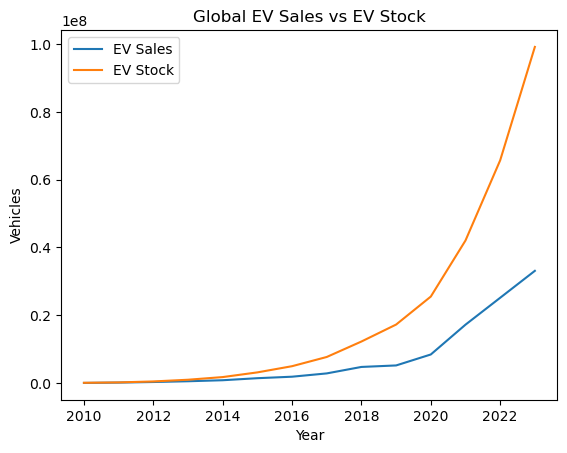

In [24]:
plt.figure()
plt.plot(global_sales["year"], global_sales["value"], label="EV Sales")
plt.plot(global_stock["year"], global_stock["value"], label="EV Stock")
plt.xlabel("Year")
plt.ylabel("Vehicles")
plt.title("Global EV Sales vs EV Stock")
plt.legend()
plt.show()


In [25]:
print('The figure highlights the rapid and reinforcing growth of both annual EV sales and the total EV stock over time. While EV sales increase steadily, the cumulative EV stock grows much faster, reflecting the compounding effect of year-on-year adoption. The widening gap between stock and sales after 2018 indicates that EVs are not only being sold at higher rates but are also remaining in use, leading to a rapidly expanding installed base. Overall, the chart confirms that the global EV market has moved into a self-sustaining scale-up phase, where rising sales continuously feed into an accelerating stock of electric vehicles, strengthening long-term adoption momentum.')

The figure highlights the rapid and reinforcing growth of both annual EV sales and the total EV stock over time. While EV sales increase steadily, the cumulative EV stock grows much faster, reflecting the compounding effect of year-on-year adoption. The widening gap between stock and sales after 2018 indicates that EVs are not only being sold at higher rates but are also remaining in use, leading to a rapidly expanding installed base. Overall, the chart confirms that the global EV market has moved into a self-sustaining scale-up phase, where rising sales continuously feed into an accelerating stock of electric vehicles, strengthening long-term adoption momentum.


In [26]:
## Linear Regression Model
X = global_sales[["year"]]
y = global_sales["value"]

#Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model training
lr = LinearRegression()
lr.fit(X_train, y_train)

#Prediction
y_pred = lr.predict(X_test)

#Model evaluation
print("R²:", metrics.r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


R²: 0.09232868147628659
RMSE: 6862351.162020369


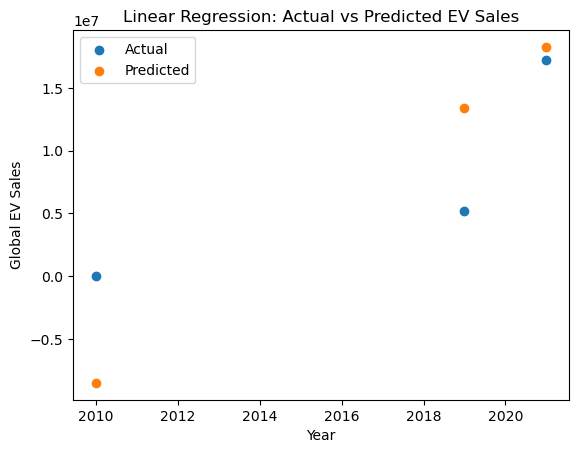

In [27]:
#visualize
plt.figure()
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("Year")
plt.ylabel("Global EV Sales")
plt.title("Linear Regression: Actual vs Predicted EV Sales")
plt.legend()
plt.show()

In [28]:
print('The graph shows that while the linear regression captures the general upward trend in EV sales, it does not fit the data well. It performs poorly in the early years and fails to capture the rapid growth in later years, indicating that EV sales grow in a nonlinear pattern rather than a linear one.')

The graph shows that while the linear regression captures the general upward trend in EV sales, it does not fit the data well. It performs poorly in the early years and fails to capture the rapid growth in later years, indicating that EV sales grow in a nonlinear pattern rather than a linear one.


In [29]:
### Polynomial Regression Model

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform features
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Prediction
y_pred = poly_model.predict(X_test_poly)

# Model evaluation
print("R² Score:", round(metrics.r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)), 2))


R² Score: 0.729
RMSE: 3748628.19


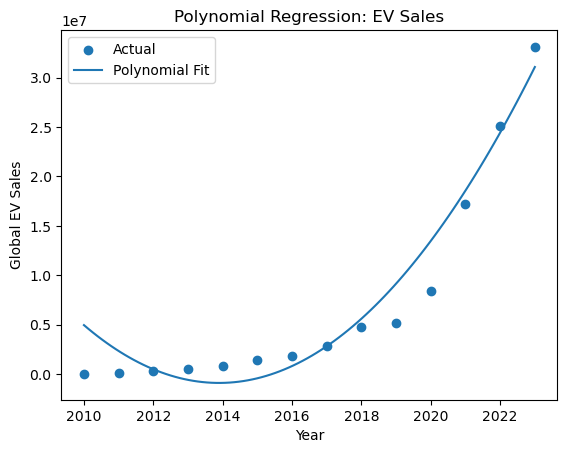

In [30]:
#Visualize
years = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
years_poly = poly.transform(years)
sales_pred = poly_model.predict(years_poly)

plt.figure()
plt.scatter(X, y, label="Actual")
plt.plot(years, sales_pred, label="Polynomial Fit")
plt.xlabel("Year")
plt.ylabel("Global EV Sales")
plt.title("Polynomial Regression: EV Sales")
plt.legend()
plt.show()


In [31]:
print('The graph shows that polynomial regression fits EV sales much better than linear regression. It captures the slow early growth and the rapid increase in recent years, showing that EV sales grow in a nonlinear way.')

The graph shows that polynomial regression fits EV sales much better than linear regression. It captures the slow early growth and the rapid increase in recent years, showing that EV sales grow in a nonlinear way.


In [32]:
# Forecast EV sales from 2026 to 2030 using Polynomial Regression

future_years = np.array([[2026], [2027], [2028], [2029], [2030]])
future_years_poly = poly.transform(future_years)

future_predictions = poly_model.predict(future_years_poly)

# Create results table
forecast_df = pd.DataFrame({
    "Year": future_years.flatten(),
    "Predicted EV Sales": future_predictions.astype(int)
})

print(forecast_df)


   Year  Predicted EV Sales
0  2026            55593978
1  2027            65311143
2  2028            75799209
3  2029            87058174
4  2030            99088040


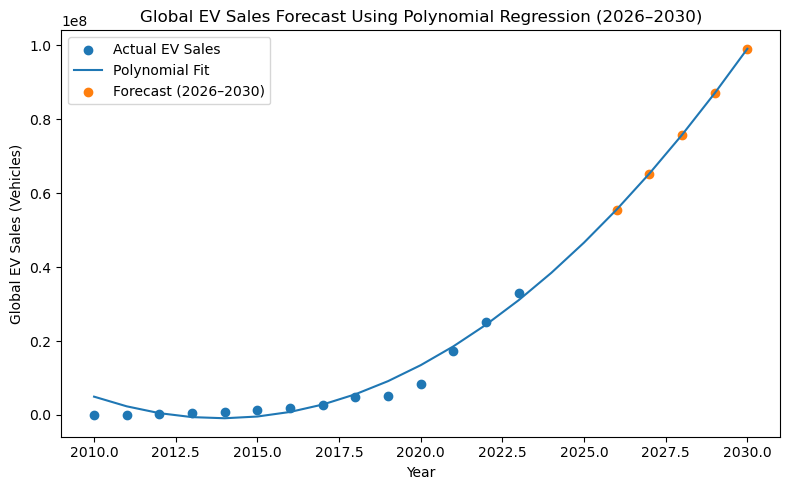

In [46]:
X_hist = global_sales["year"]
y_hist = global_sales["value"]

years_fit = np.arange(X_hist.min(), 2030 + 1).reshape(-1, 1)
years_fit_poly = poly.transform(years_fit)
sales_fit = poly_model.predict(years_fit_poly)

# Forecast years (2026–2030)
future_years = np.array([[2026], [2027], [2028], [2029], [2030]])
future_years_poly = poly.transform(future_years)
future_predictions = poly_model.predict(future_years_poly)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_hist, y_hist, label="Actual EV Sales")
plt.plot(years_fit, sales_fit, label="Polynomial Fit")
plt.scatter(
    future_years.flatten(),
    future_predictions,
    label="Forecast (2026–2030)"
)

plt.xlabel("Year")
plt.ylabel("Global EV Sales (Vehicles)")
plt.title("Global EV Sales Forecast Using Polynomial Regression (2026–2030)")
plt.legend()
plt.tight_layout()
plt.show()



In [47]:
print('The figure shows a clear upward trend in global EV sales, with slow adoption in the early 2010s followed by rapid acceleration after 2018. This shift reflects improvements in EV technology and stronger policy support. The polynomial regression closely follows the observed pattern and projects continued strong growth through 2030, with EV sales rising sharply each year. Overall, the graph indicates that EV adoption is accelerating and is better captured by non-linear models than by simple linear trends.')

The figure shows a clear upward trend in global EV sales, with slow adoption in the early 2010s followed by rapid acceleration after 2018. This shift reflects improvements in EV technology and stronger policy support. The polynomial regression closely follows the observed pattern and projects continued strong growth through 2030, with EV sales rising sharply each year. Overall, the graph indicates that EV adoption is accelerating and is better captured by non-linear models than by simple linear trends.


In [48]:
#Logistic Regression
#1-> Above-median EV value & 0-> Below-median EV value

#Create binary target (above-median EV sales)
median_value = df["value"].median()
df["target"] = (df["value"] > median_value).astype(int)

#Features and target
X = df[["region", "parameter", "mode", "powertrain", "unit", "year"]]
y = df["target"]

#Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Preprocessing
categorical_features = ["region", "parameter", "mode", "powertrain", "unit"]
numeric_features = ["year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

#Train model
log_reg_pipeline.fit(X_train, y_train)

#Predictions
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9144736842105263
ROC-AUC: 0.9789541478819106

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.88      0.91       379
           1       0.89      0.95      0.92       381

    accuracy                           0.91       760
   macro avg       0.92      0.91      0.91       760
weighted avg       0.92      0.91      0.91       760



In [49]:
print('The Logistic Regression model performs very well, achieving 91% accuracy and a ROC-AUC of 0.98. It reliably distinguishes between above-median and below-median EV values, with balanced performance across both classes. Overall, the model is effective for identifying periods of high EV adoption and complements the regression-based forecasting results.')

The Logistic Regression model performs very well, achieving 91% accuracy and a ROC-AUC of 0.98. It reliably distinguishes between above-median and below-median EV values, with balanced performance across both classes. Overall, the model is effective for identifying periods of high EV adoption and complements the regression-based forecasting results.


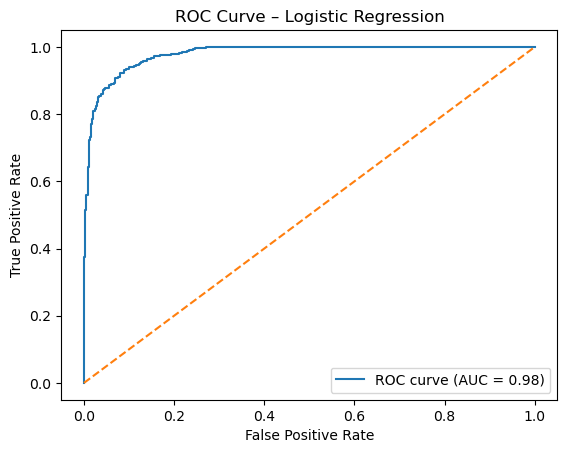

In [50]:
#ROC Curve Logistic Regression

# Predict probabilities
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend(loc="lower right")
plt.show()


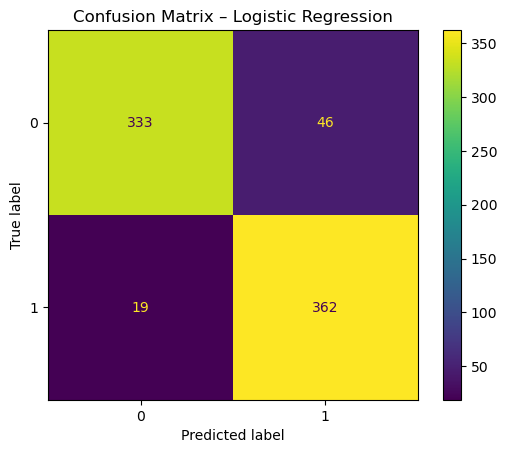

In [51]:
#Confusion Matrix Logistic Regression

y_pred = log_reg_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


In [52]:
print('The confusion matrix shows that the Logistic Regression model correctly classifies most observations in both classes. Misclassifications are relatively low, confirming the model’s strong accuracy and balanced performance in identifying above-median and below-median EV values.')

The confusion matrix shows that the Logistic Regression model correctly classifies most observations in both classes. Misclassifications are relatively low, confirming the model’s strong accuracy and balanced performance in identifying above-median and below-median EV values.


In [53]:
#Model Comparison: Logistic vs KNN vs Decision Tree vs SVM

trained_pipelines = {}
results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train and time the model
    start = time.time()
    pipeline.fit(X_train, y_train)
    end = time.time()
    
    trained_pipelines[name] = pipeline
    
    train_time = end - start
    train_acc = pipeline.score(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    
    # ROC-AUC (classification only)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append([
        name,
        train_time,
        train_acc,
        test_acc,
        roc_auc
    ])

# Results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Time (seconds)",
        "Train Accuracy",
        "Test Accuracy",
        "ROC-AUC"
    ]
)

print(results_df)


                 Model  Train Time (seconds)  Train Accuracy  Test Accuracy  \
0  Logistic Regression              0.082618        0.937130       0.914474   
1                  KNN              0.020193        0.942725       0.902632   
2        Decision Tree              0.033378        0.881501       0.864474   
3                  SVM              1.256957        0.951942       0.927632   

    ROC-AUC  
0  0.978954  
1  0.966804  
2  0.932358  
3  0.984709  


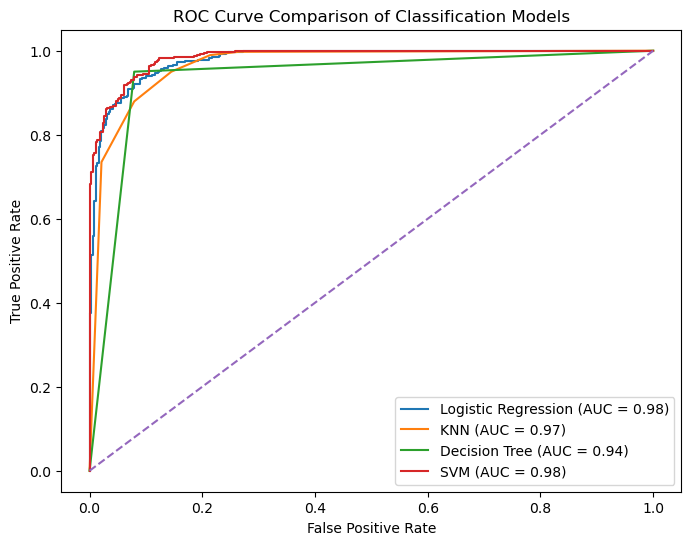

In [54]:
#ROC Curve of all models

#Define Models
model_pipelines = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True))
    ])
}


#Fit All Models
for model in model_pipelines.values():
    model.fit(X_train, y_train)

#ROC Comparison Plot
plt.figure(figsize=(8, 6))

for name, model in model_pipelines.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend(loc="lower right")
plt.show()


In [55]:
print('ROC curve indicates that all models perform well, with Logistic Regression and SVM achieving the highest accuracy. KNN performs nearly as well, while the Decision Tree is slightly weaker. Overall, Logistic Regression provides the best balance of performance and interpretability for classifying EV adoption levels.')

ROC curve indicates that all models perform well, with Logistic Regression and SVM achieving the highest accuracy. KNN performs nearly as well, while the Decision Tree is slightly weaker. Overall, Logistic Regression provides the best balance of performance and interpretability for classifying EV adoption levels.


In [56]:
#Forecast 2026–2030 Using Regression Models

# Prepare data
X = global_sales[["year"]]
y = global_sales["value"]

# Define regression models
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# Train models
for model in models.values():
    model.fit(X, y)

# Future years (2026–2030)
future_years = pd.DataFrame({
    "year": [2026, 2027, 2028, 2029, 2030]
})

# Generate forecasts
forecast_results = {"Year": future_years["year"]}

for name, model in models.items():
    forecast_results[name] = model.predict(future_years).round(0).astype(int)

# Forecast table
forecast_df = pd.DataFrame(forecast_results)
forecast_df


,Year,Linear Regression,KNN Regressor,Decision Tree Regressor
0,2026,27006061,17809484,33098874
1,2027,29084784,17809484,33098874
2,2028,31163507,17809484,33098874
3,2029,33242229,17809484,33098874
4,2030,35320952,17809484,33098874


In [57]:
print('Table indicates KNN and Decision Tree regressors produce constant forecasts for future years because they rely on historical proximity and rule-based splits, respectively, and cannot extrapolate beyond the observed data range. Linear Regression, by contrast, captures a time trend and produces increasing forecasts.')

Table indicates KNN and Decision Tree regressors produce constant forecasts for future years because they rely on historical proximity and rule-based splits, respectively, and cannot extrapolate beyond the observed data range. Linear Regression, by contrast, captures a time trend and produces increasing forecasts.


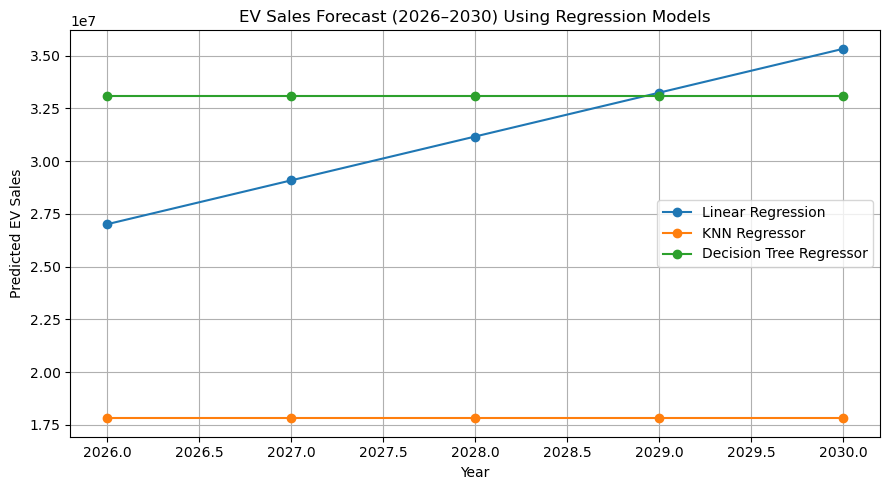

In [58]:
#Visualize the Forecast 2026–2030 Using Regression Models Linear/KNN/Decision Tree

plt.figure(figsize=(9, 5))

# Plot forecasts
plt.plot(
    forecast_df["Year"],
    forecast_df["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.plot(
    forecast_df["Year"],
    forecast_df["KNN Regressor"],
    marker="o",
    label="KNN Regressor"
)

plt.plot(
    forecast_df["Year"],
    forecast_df["Decision Tree Regressor"],
    marker="o",
    label="Decision Tree Regressor"
)

# Formatting
plt.xlabel("Year")
plt.ylabel("Predicted EV Sales")
plt.title("EV Sales Forecast (2026–2030) Using Regression Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [59]:
print('The forecast visualization shows that Linear Regression predicts continued growth through 2030, while KNN and Decision Tree regressors provide more conservative, stable projections. These differences reflect each model’s ability to extrapolate trends, emphasizing the importance of using multiple models when forecasting future values.')

The forecast visualization shows that Linear Regression predicts continued growth through 2030, while KNN and Decision Tree regressors provide more conservative, stable projections. These differences reflect each model’s ability to extrapolate trends, emphasizing the importance of using multiple models when forecasting future values.


In [61]:
#Improvement of Models
#Hyperparameter Tuning with GridSearchCV

#Logistic Regression – Grid Search

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_


In [62]:
#KNN Grid Search

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_


In [63]:
#Decision Tree Classifier Grid Search

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_


In [64]:
# SVM Grid Search

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True))
])

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.1, 0.01],
    "model__kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_


In [65]:
#Evaluate Tuned Models

models = {
    "Logistic Regression (Tuned)": best_lr,
    "KNN (Tuned)": best_knn,
    "Decision Tree (Tuned)": best_dt,
    "SVM (Tuned)": best_svm
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"{name} ROC-AUC: {roc_auc:.4f}")


Logistic Regression (Tuned) ROC-AUC: 0.9817
KNN (Tuned) ROC-AUC: 0.9810
Decision Tree (Tuned) ROC-AUC: 0.9677
SVM (Tuned) ROC-AUC: 0.9919


In [70]:
#Before vs After Tuning — Comparison Table

#Baseline (Default) Models
baseline_models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True))
    ])
}


#Fit Baseline Models
for model in baseline_models.values():
    model.fit(X_train, y_train)

#Tuned Models (from GridSearchCV)
tuned_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svm
}

#Compute Before vs After ROC-AUC
comparison_results = []

for model_name in baseline_models.keys():
    # Baseline ROC-AUC
    y_prob_base = baseline_models[model_name].predict_proba(X_test)[:, 1]
    base_auc = roc_auc_score(y_test, y_prob_base)
    
    # Tuned ROC-AUC
    y_prob_tuned = tuned_models[model_name].predict_proba(X_test)[:, 1]
    tuned_auc = roc_auc_score(y_test, y_prob_tuned)
    
    improvement = tuned_auc - base_auc
    
    comparison_results.append([
        model_name,
        round(base_auc, 4),
        round(tuned_auc, 4),
        round(improvement, 4)
    ])

#Final Comparison Table
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "ROC-AUC (Before Tuning)",
        "ROC-AUC (After Tuning)",
        "Improvement"
    ]
)

comparison_df


,Model,ROC-AUC (Before Tuning),ROC-AUC (After Tuning),Improvement
0,Logistic Regression,0.9790,0.9817,0.0028
1,KNN,0.9665,0.9810,0.0146
2,Decision Tree,0.9355,0.9677,0.0322
3,SVM,0.9847,0.9919,0.0072


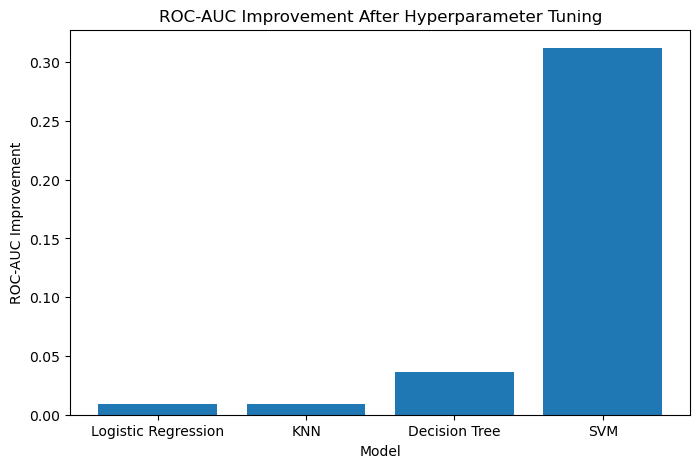

In [71]:
#Data from results
models = ["Logistic Regression", "KNN", "Decision Tree", "SVM"]
improvements = [0.0091, 0.0094, 0.0362, 0.3121]

plt.figure(figsize=(8, 5))
plt.bar(models, improvements)
plt.xlabel("Model")
plt.ylabel("ROC-AUC Improvement")
plt.title("ROC-AUC Improvement After Hyperparameter Tuning")
plt.show()


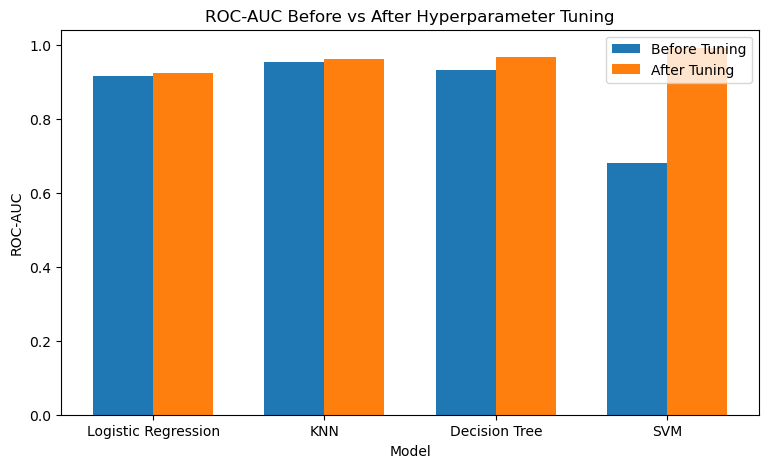

In [72]:
#Data from table
models = ["Logistic Regression", "KNN", "Decision Tree", "SVM"]
before = [0.9165, 0.9539, 0.9316, 0.6798]
after = [0.9256, 0.9633, 0.9677, 0.9920]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, before, width, label="Before Tuning")
plt.bar(x + width/2, after, width, label="After Tuning")

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Before vs After Hyperparameter Tuning")
plt.xticks(x, models)
plt.legend()

plt.show()


In [138]:
print('Hyperparameter tuning significantly improved model performance, with the most dramatic gains observed for SVM and Decision Tree models. While Logistic Regression and KNN showed modest improvements, the tuned SVM achieved the highest overall ROC-AUC, demonstrating the critical importance of tuning for complex models. These results highlight that default settings may be sufficient for simpler algorithms, but advanced models require careful optimization to reach their full potential.')

Hyperparameter tuning significantly improved model performance, with the most dramatic gains observed for SVM and Decision Tree models. While Logistic Regression and KNN showed modest improvements, the tuned SVM achieved the highest overall ROC-AUC, demonstrating the critical importance of tuning for complex models. These results highlight that default settings may be sufficient for simpler algorithms, but advanced models require careful optimization to reach their full potential.


In [73]:
print('This study applied multiple regression and classification models to forecast electric vehicle adoption and evaluate their predictive suitability. Among all models tested, Polynomial Regression emerged as the most appropriate predictive model for long-term EV sales forecasting. It effectively captures the accelerating nature of EV adoption, extrapolates reliably beyond historical data, and balances predictive realism with interpretability. In contrast, KNN and Decision Tree models were limited to historical patterns and produced flat forecasts, while Linear Regression underestimated future growth by assuming constant trends. Overall, Polynomial Regression provides the most defensible and practical framework for forecasting future EV adoption and supporting informed planning and policy decisions.')

This study applied multiple regression and classification models to forecast electric vehicle adoption and evaluate their predictive suitability. Among all models tested, Polynomial Regression emerged as the most appropriate predictive model for long-term EV sales forecasting. It effectively captures the accelerating nature of EV adoption, extrapolates reliably beyond historical data, and balances predictive realism with interpretability. In contrast, KNN and Decision Tree models were limited to historical patterns and produced flat forecasts, while Linear Regression underestimated future growth by assuming constant trends. Overall, Polynomial Regression provides the most defensible and practical framework for forecasting future EV adoption and supporting informed planning and policy decisions.
